# Task 1 

In [3]:


import pandas as pd
import plotly.express as px
import json
import urllib.request

df = px.data.gapminder()

# Filter year
gm_2007 = df[df["year"] == 2007].copy()

# global average
global_avg_life_exp = gm_2007["lifeExp"].mean()

# deviation from global average
gm_2007["lifeExp_deviation"] = gm_2007["lifeExp"] - global_avg_life_exp

region_deviation = gm_2007.groupby("continent")["lifeExp_deviation"].mean()
furthest_below_region = region_deviation.idxmin()
furthest_below_value = region_deviation.min()

print("Global average life expectancy in 2007:", round(global_avg_life_exp, 2))
print("Region furthest below global average:", furthest_below_region)
print("Average deviation of this region:", round(furthest_below_value, 2))

# choropleth map
fig = px.choropleth(
    gm_2007,
    locations="iso_alpha",
    color="lifeExp_deviation",
    hover_name="country",
    hover_data={
        "lifeExp": ":.2f",
        "lifeExp_deviation": ":.2f",
        "continent": True,
        "iso_alpha": False
    },
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0,
    title=f"Life Expectancy Deviation from Global Average in 2007 — {furthest_below_region} is furthest below average",
    labels={
        "lifeExp_deviation": "Deviation from Global Average",
        "lifeExp": "Life Expectancy",
        "continent": "Region"
    }
)

# map layout
fig.update_geos(
    showcoastlines=True,
    showland=True,
    fitbounds="locations"
)

fig.update_layout(
    title_x=0.5,
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.show()

Global average life expectancy in 2007: 67.01
Region furthest below global average: Africa
Average deviation of this region: -12.2


AFG
{'name': 'Afghanistan'}


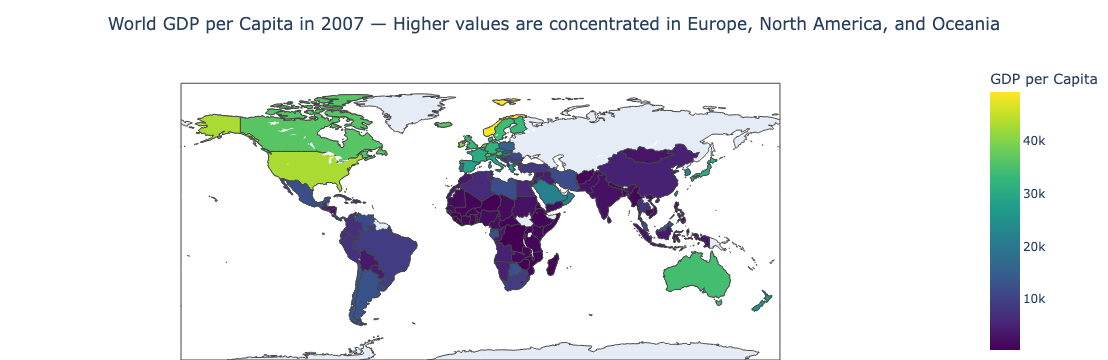

In [4]:
# Task 2 — Find your own GeoJSON



# Load GeoJSON 
geojson_url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"

with urllib.request.urlopen(geojson_url) as response:
    world_geojson = json.load(response)

#find the correct featureidkey
print(world_geojson["features"][0]["id"])
print(world_geojson["features"][0]["properties"])

df = px.data.gapminder()

# 4. Use only 2007 data
gm_2007 = df[df["year"] == 2007].copy()

# choropleth map
fig = px.choropleth(
    gm_2007,
    geojson=world_geojson,
    locations="iso_alpha",
    featureidkey="id",
    color="gdpPercap",
    hover_name="country",
    hover_data={
        "continent": True,
        "pop": ":,",
        "lifeExp": ":.2f",
        "gdpPercap": ":.2f",
        "iso_alpha": False
    },
    color_continuous_scale="Viridis",
    title="World GDP per Capita in 2007 — Higher values are concentrated in Europe, North America, and Oceania",
    labels={
        "gdpPercap": "GDP per Capita",
        "continent": "Region",
        "pop": "Population",
        "lifeExp": "Life Expectancy"
    }
)

# layout
fig.update_geos(
    showcoastlines=True,
    showland=True,
    fitbounds="locations"
)

fig.update_layout(
    title_x=0.5,
    margin=dict(l=0, r=0, t=60, b=0)
)

fig.show()